In [1]:
# ── Imports ──
# Standard pipeline imports plus pybaseball for Statcast data
import sys
sys.path.append("../scripts")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.stats import poisson
from sqlalchemy import text
from sklearn.linear_model import PoissonRegressor, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from pybaseball import statcast_batter
from data_collection import engine

In [2]:
# ── Load base dataset from database ──
# Same query as v3 — pitcher stats, bullpen, park factors joined to Witt game logs
with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            w.game_id,
            w.date,
            w.season,
            w.home_away,
            w.tb,
            w.opponent_id,
            p.throws,
            p.era,
            p.whip,
            p.k_per_9,
            p.era_last5,
            p.whip_last5,
            p.k_per_9_last5,
            p.era_vs_rhb,
            p.whip_vs_rhb,
            b.bullpen_era,
            b.bullpen_whip,
            b.bullpen_k_per_9,
            pf.park_factor,
            pf.park_factor_hr
        FROM witt_game_logs w
        JOIN pitcher_game_logs p ON w.game_id = p.game_id
        JOIN bullpen_stats b ON w.game_id = b.game_id
        JOIN park_factors pf ON (
            CASE WHEN w.home_away = 'home' THEN 118
                 ELSE w.opponent_id
            END = pf.team_id
        )
        ORDER BY w.date
    """), conn)

print(f"Base dataset: {df.shape}")
print(df.head())

Base dataset: (626, 20)
   game_id        date  season home_away  tb  opponent_id throws  era  whip  \
0   662766  2022-04-07    2022      home   2          114      R  4.2   1.3   
1   662765  2022-04-09    2022      home   0          114      R  4.2   1.3   
2   662755  2022-04-10    2022      home   2          114      R  4.2   1.3   
3   662754  2022-04-11    2022      home   0          114      R  4.2   1.3   
4   662017  2022-04-12    2022      away   0          138      R  4.2   1.3   

   k_per_9  era_last5  whip_last5  k_per_9_last5  era_vs_rhb  whip_vs_rhb  \
0      8.8        4.2         1.3            8.8         4.2          1.3   
1      8.8        4.2         1.3            8.8         4.2          1.3   
2      8.8        4.2         1.3            8.8         4.2          1.3   
3      8.8        4.2         1.3            8.8         4.2          1.3   
4      8.8        4.2         1.3            8.8         4.2          1.3   

   bullpen_era  bullpen_whip  bullpen_

In [3]:
# ── Pull Statcast data for Bobby Witt Jr. via pybaseball ──
# Returns pitch-level data — one row per pitch across all games 2022-2025
# Key columns: launch_speed (exit velo), launch_angle, launch_speed_angle (barrel = 6), events
print("Pulling Statcast data from Baseball Savant via pybaseball...")
statcast_raw = statcast_batter('2022-04-01', '2025-10-01', player_id=677951)
print(f"Statcast raw: {statcast_raw.shape} (one row per pitch)")

Pulling Statcast data from Baseball Savant via pybaseball...
Gathering Player Data
Statcast raw: (10689, 118) (one row per pitch)


In [4]:
# ── Aggregate Statcast to game level ──
# Filter to batted balls only — NaN launch_speed means pitch wasn't put in play
batted = statcast_raw[statcast_raw['launch_speed'].notna()].copy()

game_stats = batted.groupby('game_date').agg(
    avg_exit_velo=('launch_speed', 'mean'),
    max_exit_velo=('launch_speed', 'max'),
    # Barrel = launch_speed_angle of 6 (optimal exit velo + launch angle combo)
    barrel_count=('launch_speed_angle', lambda x: (x == 6).sum()),
    # Hard hit = 95mph or higher exit velocity
    hard_hit_count=('launch_speed', lambda x: (x >= 95).sum()),
    batted_balls=('launch_speed', 'count'),
).reset_index()

# Compute rates — barrels and hard hits as a fraction of total batted balls
game_stats['barrel_rate']   = game_stats['barrel_count']   / game_stats['batted_balls']
game_stats['hard_hit_rate'] = game_stats['hard_hit_count'] / game_stats['batted_balls']

print(f"Game-level Statcast: {game_stats.shape}")
print(game_stats.head())

Game-level Statcast: (641, 8)
    game_date  avg_exit_velo  max_exit_velo  barrel_count  hard_hit_count  \
0  2022-04-07      91.575000          110.4             0               1   
1  2022-04-09      79.837500           96.5             0               2   
2  2022-04-10      77.350000          110.1             0               1   
3  2022-04-11      83.700000          103.3             0               1   
4  2022-04-12      84.833333           97.1             0               1   

   batted_balls  barrel_rate  hard_hit_rate  
0             4          0.0       0.250000  
1             8          0.0       0.250000  
2            10          0.0       0.100000  
3             4          0.0       0.250000  
4             3          0.0       0.333333  


In [5]:
# ── Compute rolling Statcast features ──
# shift(1) so current game's contact quality never leaks into its own prediction
game_stats = game_stats.sort_values('game_date').reset_index(drop=True)

game_stats['avg_exit_velo_7']  = game_stats['avg_exit_velo'].shift(1).rolling(7,  min_periods=3).mean()
game_stats['avg_exit_velo_15'] = game_stats['avg_exit_velo'].shift(1).rolling(15, min_periods=7).mean()
game_stats['barrel_rate_7']    = game_stats['barrel_rate'].shift(1).rolling(7,  min_periods=3).mean()
game_stats['barrel_rate_15']   = game_stats['barrel_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hard_hit_rate_7']  = game_stats['hard_hit_rate'].shift(1).rolling(7,  min_periods=3).mean()

print(game_stats[['game_date', 'avg_exit_velo', 'avg_exit_velo_7', 'barrel_rate_7', 'hard_hit_rate_7']].head(15))

     game_date  avg_exit_velo  avg_exit_velo_7  barrel_rate_7  hard_hit_rate_7
0   2022-04-07      91.575000              NaN            NaN              NaN
1   2022-04-09      79.837500              NaN            NaN              NaN
2   2022-04-10      77.350000              NaN            NaN              NaN
3   2022-04-11      83.700000        82.920833            0.0         0.200000
4   2022-04-12      84.833333        83.115625            0.0         0.212500
5   2022-04-14      85.000000        83.459167            0.0         0.236667
6   2022-04-15      85.316667        83.715972            0.0         0.252778
7   2022-04-16      76.585714        83.944643            0.0         0.264286
8   2022-04-19      86.240000        81.803316            0.0         0.228571
9   2022-04-20      90.566667        82.717959            0.0         0.250000
10  2022-04-21      79.060000        84.606054            0.0         0.283333
11  2022-04-22      88.200000        83.943197      

In [6]:
# ── Merge Statcast features into base dataset ──
# Left join on date — keeps all base dataset rows, adds Statcast where available
game_stats['game_date'] = pd.to_datetime(game_stats['game_date'])
df['date'] = pd.to_datetime(df['date'])

df = df.merge(
    game_stats[['game_date', 'avg_exit_velo_7', 'avg_exit_velo_15',
                'barrel_rate_7', 'barrel_rate_15', 'hard_hit_rate_7']],
    left_on='date',
    right_on='game_date',
    how='left'
)

print(f"After merge: {df.shape}")
print(df[['avg_exit_velo_7', 'barrel_rate_7', 'hard_hit_rate_7']].isnull().sum())

After merge: (626, 26)
avg_exit_velo_7    3
barrel_rate_7      3
hard_hit_rate_7    3
dtype: int64


In [7]:
# ── Feature engineering — TB rolling features ──
df = df.sort_values('date').reset_index(drop=True)

df['tb_avg_7']  = df['tb'].shift(1).rolling(7,  min_periods=3).mean()
df['tb_avg_15'] = df['tb'].shift(1).rolling(15, min_periods=7).mean()
df['tb_lag1']   = df['tb'].shift(1)
df['is_home']   = (df['home_away'] == 'home').astype(int)
df['pitcher_r'] = (df['throws'] == 'R').astype(int)

# Drop rows missing any rolling features
df_model = df.dropna(subset=['tb_avg_7', 'tb_avg_15', 'tb_lag1',
                              'avg_exit_velo_7', 'barrel_rate_7']).reset_index(drop=True)

print(f"Model dataset: {df_model.shape}")
print(df_model.isnull().sum())

Model dataset: (619, 31)
game_id             0
date                0
season              0
home_away           0
tb                  0
opponent_id         0
throws              0
era                 0
whip                0
k_per_9             0
era_last5           0
whip_last5          0
k_per_9_last5       0
era_vs_rhb          0
whip_vs_rhb         0
bullpen_era         0
bullpen_whip        0
bullpen_k_per_9     0
park_factor         0
park_factor_hr      0
game_date           0
avg_exit_velo_7     0
avg_exit_velo_15    0
barrel_rate_7       0
barrel_rate_15      0
hard_hit_rate_7     0
tb_avg_7            0
tb_avg_15           0
tb_lag1             0
is_home             0
pitcher_r           0
dtype: int64


In [8]:
# ── Define features and target ──
# V4 additions: avg_exit_velo_7, avg_exit_velo_15, barrel_rate_7, 
# barrel_rate_15, hard_hit_rate_7 — Witt's own contact quality signal
FEATURES = [
    # Witt recent TB form
    'tb_lag1',
    'tb_avg_7',
    'tb_avg_15',
    # Witt contact quality — NEW in v4
    'avg_exit_velo_7',
    'avg_exit_velo_15',
    'barrel_rate_7',
    'barrel_rate_15',
    'hard_hit_rate_7',
    # Game context
    'is_home',
    'pitcher_r',
    # Starter season stats
    'era',
    'whip',
    'k_per_9',
    # Starter recent form
    'era_last5',
    'whip_last5',
    # Starter vs RHB
    'era_vs_rhb',
    # Bullpen
    'bullpen_era',
    'bullpen_whip',
    # Park
    'park_factor',
    'park_factor_hr',
]

TARGET = 'tb'

X = df_model[FEATURES]
y = df_model[TARGET]

print(f"Features: {len(FEATURES)}")
print(f"Dataset: {X.shape}")
print(y.describe())

Features: 20
Dataset: (619, 20)
count    619.000000
mean       2.017771
std        1.993032
min        0.000000
25%        0.500000
50%        2.000000
75%        3.000000
max       11.000000
Name: tb, dtype: float64


In [9]:
# ── Scale features ──
# Poisson regression is a linear model — sensitive to feature scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

In [10]:
# ── Baseline ──
naive_pred = np.full(len(y), y.mean())
naive_mae  = mean_absolute_error(y, naive_pred)
print(f"Naive baseline MAE (always predict mean): {naive_mae:.3f}")

Naive baseline MAE (always predict mean): 1.511


In [11]:
# ── Cross-validation ──
model = PoissonRegressor(alpha=1.0, max_iter=300)
tscv  = TimeSeriesSplit(n_splits=5)

cv_mae  = -cross_val_score(model, X_scaled, y, cv=tscv, scoring='neg_mean_absolute_error')
cv_rmse = -cross_val_score(model, X_scaled, y, cv=tscv, scoring='neg_root_mean_squared_error')

print(f"CV MAE  per fold: {[round(v,3) for v in cv_mae]}")
print(f"CV RMSE per fold: {[round(v,3) for v in cv_rmse]}")
print(f"\nMAE  mean ± std: {cv_mae.mean():.3f} ± {cv_mae.std():.3f}")
print(f"RMSE mean ± std: {cv_rmse.mean():.3f} ± {cv_rmse.std():.3f}")
print(f"\nBaseline MAE:    {naive_mae:.3f}")
print(f"Improvement:     {naive_mae - cv_mae.mean():.3f}")
print(f"\n── vs V3 Poisson (MAE 1.504) ──")
print(f"Delta from V3:   {1.504 - cv_mae.mean():.3f}")

CV MAE  per fold: [np.float64(1.369), np.float64(1.751), np.float64(1.623), np.float64(1.357), np.float64(1.452)]
CV RMSE per fold: [np.float64(1.825), np.float64(2.344), np.float64(2.26), np.float64(1.808), np.float64(1.782)]

MAE  mean ± std: 1.510 ± 0.153
RMSE mean ± std: 2.004 ± 0.245

Baseline MAE:    1.511
Improvement:     0.001

── vs V3 Poisson (MAE 1.504) ──
Delta from V3:   -0.006


In [12]:
# ── Fit on full dataset ──
model.fit(X_scaled, y)

lambda_preds  = model.predict(X_scaled)
insample_mae  = mean_absolute_error(y, lambda_preds)
insample_rmse = root_mean_squared_error(y, lambda_preds)

print(f"In-sample MAE:  {insample_mae:.3f}")
print(f"In-sample RMSE: {insample_rmse:.3f}")
print(f"CV MAE:         {cv_mae.mean():.3f}")
print(f"\nGap (CV - in-sample): {cv_mae.mean() - insample_mae:.3f}")
print("(large gap = overfitting)")

In-sample MAE:  1.503
In-sample RMSE: 1.958
CV MAE:         1.510

Gap (CV - in-sample): 0.007
(large gap = overfitting)


In [13]:
# ── Over/under probabilities ──
df_model['lambda']   = lambda_preds
df_model['p_over_0'] = 1 - poisson.cdf(0, lambda_preds)   # P(TB >= 1)
df_model['p_over_1'] = 1 - poisson.cdf(1, lambda_preds)   # P(TB >= 2, over 1.5)
df_model['p_over_2'] = 1 - poisson.cdf(2, lambda_preds)   # P(TB >= 3, over 2.5)

print(df_model[['date', 'tb', 'lambda', 'p_over_0', 'p_over_1', 'p_over_2']].head(10))
print(f"\nMean predicted lambda: {lambda_preds.mean():.3f}")
print(f"Mean P(over 1.5 TB):   {df_model['p_over_1'].mean():.3f}")
print(f"Actual rate over 1.5:  {(y >= 2).mean():.3f}")

        date  tb    lambda  p_over_0  p_over_1  p_over_2
0 2022-04-16   2  2.245660  0.894142  0.656422  0.389503
1 2022-04-19   0  1.937117  0.855881  0.576706  0.306309
2 2022-04-20   0  2.168682  0.885672  0.637730  0.368877
3 2022-04-21   2  1.885927  0.848312  0.562238  0.292482
4 2022-04-22   1  1.716120  0.820238  0.511744  0.247038
5 2022-04-23   2  1.505897  0.778182  0.444146  0.192635
6 2022-04-24   1  1.506266  0.778264  0.444270  0.192728
7 2022-04-26   3  1.819792  0.837941  0.543026  0.274684
8 2022-04-27   1  1.526919  0.782796  0.451143  0.197940
9 2022-04-28   1  1.576865  0.793378  0.467563  0.210680

Mean predicted lambda: 2.018
Mean P(over 1.5 TB):   0.595
Actual rate over 1.5:  0.507


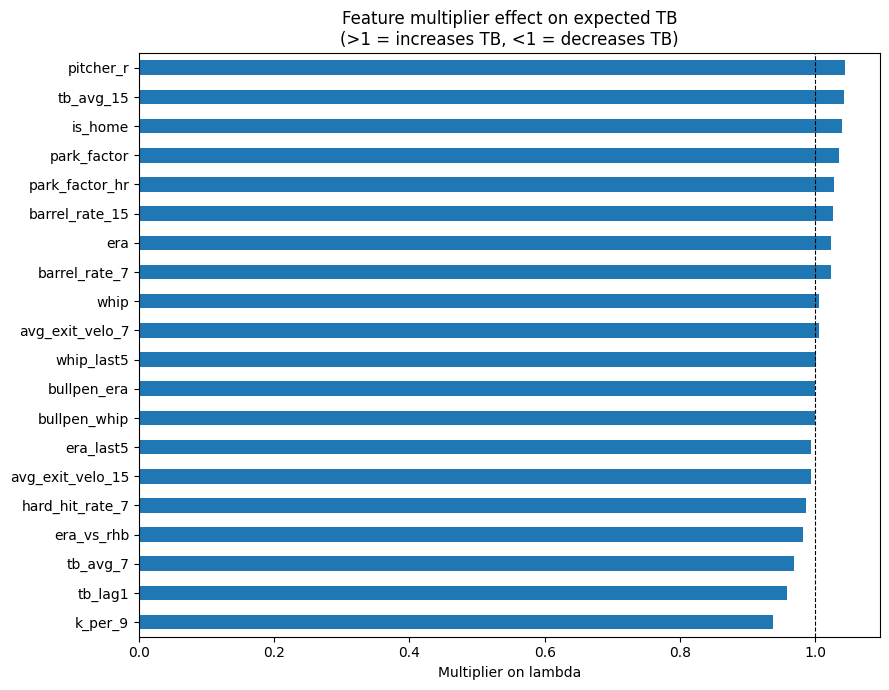


Multiplier effect on lambda:
k_per_9             0.937
tb_lag1             0.958
tb_avg_7            0.968
era_vs_rhb          0.982
hard_hit_rate_7     0.986
avg_exit_velo_15    0.994
era_last5           0.994
bullpen_whip        0.999
bullpen_era         1.000
whip_last5          1.001
avg_exit_velo_7     1.006
whip                1.006
barrel_rate_7       1.023
era                 1.024
barrel_rate_15      1.027
park_factor_hr      1.029
park_factor         1.036
is_home             1.039
tb_avg_15           1.043
pitcher_r           1.044
dtype: float64


In [14]:
# ── Feature coefficients ──
# exp(coef) = multiplier effect on expected TB
# >1 increases expected TB, <1 decreases it
coefs = pd.Series(model.coef_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
np.exp(coefs).sort_values().plot(kind='barh', ax=ax)
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Feature multiplier effect on expected TB\n(>1 = increases TB, <1 = decreases TB)')
ax.set_xlabel('Multiplier on lambda')
plt.tight_layout()
plt.show()

print("\nMultiplier effect on lambda:")
print(np.exp(coefs).round(3))

In [15]:
# ── Platt scaling calibration ──
# Corrects the raw probability output to match true historical rates
y_binary = (y >= 2).astype(int)
p_raw    = df_model['p_over_1'].values.reshape(-1, 1)

platt = LogisticRegression()
platt.fit(p_raw, y_binary)

df_model['p_over_1_cal'] = platt.predict_proba(p_raw)[:, 1]

print(f"Mean raw probability:        {df_model['p_over_1'].mean():.3f}")
print(f"Mean calibrated probability: {df_model['p_over_1_cal'].mean():.3f}")
print(f"Actual rate over 1.5:        {y_binary.mean():.3f}")

Mean raw probability:        0.595
Mean calibrated probability: 0.507
Actual rate over 1.5:        0.507


In [16]:
# ── Calibration check ──
# Key question: does the model correctly rank games from low to high probability?
# Well-calibrated = predicted and actual rates close in each bin
# Wide spread in actual_rate across bins = strong discriminating power
df_model['pred_bin_cal'] = pd.qcut(df_model['p_over_1_cal'], q=5, labels=False)

calibration = df_model.groupby('pred_bin_cal').agg(
    mean_predicted=('p_over_1_cal', 'mean'),
    actual_rate=('tb', lambda x: (x >= 2).mean()),
    n=('tb', 'count')
).round(3)

print(calibration)
print(f"\nSpread (bin 4 - bin 0 actual rate): {calibration['actual_rate'].iloc[-1] - calibration['actual_rate'].iloc[0]:.3f}")
print("(larger spread = better discriminating power)")
print("\nV3 spread for comparison: 0.234 (0.613 - 0.379)")

              mean_predicted  actual_rate    n
pred_bin_cal                                  
0                      0.465        0.395  124
1                      0.492        0.444  124
2                      0.508        0.553  123
3                      0.525        0.532  124
4                      0.546        0.613  124

Spread (bin 4 - bin 0 actual rate): 0.218
(larger spread = better discriminating power)

V3 spread for comparison: 0.234 (0.613 - 0.379)


In [17]:
# ── Save model, scaler, and Platt calibrator ──
joblib.dump(model,  '../models/witt_poisson_v4_model.pkl')
joblib.dump(scaler, '../models/witt_poisson_v4_scaler.pkl')
joblib.dump(platt,  '../models/witt_poisson_v4_platt.pkl')
print("Saved:")
print("  models/witt_poisson_v4_model.pkl")
print("  models/witt_poisson_v4_scaler.pkl")
print("  models/witt_poisson_v4_platt.pkl")

Saved:
  models/witt_poisson_v4_model.pkl
  models/witt_poisson_v4_scaler.pkl
  models/witt_poisson_v4_platt.pkl
